<a href="https://colab.research.google.com/github/Santii-Alvarez/Analisis-ConnectaTel/blob/main/Project_ConnectaTel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
# importar librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
# cargar archivos

plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')#completa el código
usage = pd.read_csv('/datasets/usage.csv')  #completa el código


In [ ]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
# inspección de plans con .info()
print("plans", plans.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes
plans None


In [ ]:
# inspección de users con .info()
print("users", users.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB
users None


In [ ]:
# inspección de usage con .info()
print("usage", plans.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes
usage None


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users

print("Cantidad de valores nulos", users.isna().sum())
print("Proporción de valores nulos", users.isna().mean())


Cantidad de valores nulos user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
Proporción de valores nulos user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [ ]:
# cantidad de nulos para usage
print("Cantidad de valores nulos", usage.isna().sum())
print("Proporción de valores nulos", usage.isna().mean())


Cantidad de valores nulos id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
Proporción de valores nulos id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.
 -  

Decisiones sobre tratamiento de nulos
churn_date

Debido a que el 88.35% de los valores son nulos, se evaluó la utilidad de la columna para el análisis.
En este caso, la mayoría de registros no contienen información relevante, por lo que se decidió eliminar la columna para evitar ruido y reducir complejidad en el dataset.

city

Al tener un porcentaje moderado de valores faltantes (11.72%), se podría aplicar imputación utilizando la moda, segmentación geográfica u otras técnicas dependiendo del objetivo del análisis.

duration y length

Estas columnas presentan una alta proporción de valores nulos (55.19% y 44.74%).
Antes de imputar, sería necesario investigar si los valores faltantes dependen de la variable type, ya que podrían representar ausencia válida de información y no necesariamente errores de calidad de datos.

date

La proporción de valores faltantes es mínima (0.125%), por lo que los registros podrían eliminarse sin afectar significativamente el análisis.

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
- churn_date en un 88.35%, city en un 11.72%, duration en un 55.19% date en un 0.125% y lenght en un 44.74%
- Indica qué harías: ¿imputar, eliminar, ignorar?
- Para churn_date, haría una eliminación y para los demas trataría de imputar para no perder valores importantes.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:

# explorar columnas numéricas de users
users[["user_id", "age"]].describe()


,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000



- La columna `user_id` contiene 4000 usuarios y en general no parece tener valores faltantes.
- La columna `age` podemos observar que tenemos outliers, ya que en la edad mínima tenemos un valor de -999 que debería ser imposible, así que es necesario ajustarla.


In [ ]:
# explorar columnas numéricas de usage
usage[["id", "user_id"]].describe()

,id,user_id
count,40000.00000,40000.000000
mean,20000.50000,12002.405975
std,11547.14972,1157.279564
min,1.00000,10000.000000
25%,10000.75000,10996.000000
50%,20000.50000,12013.000000
75%,30000.25000,13005.000000
max,40000.00000,13999.000000


- Las columnas `id` y `user_id`...Haz doble clic en este bloque y escribe qué ves.
- Las columnas `id` y `user_id`, parecen estar con sus datos normales, no hay evidencia de valores faltantes o extremos, lo único podría ser que en user_id, tengamos usuarios duplicados.

In [ ]:

# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
users[columnas_user].describe()



,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595



- La columna `city` contiene 3531 valores no nulos. Además cuenta con 7 ciudades distintas, siendo Bogotá la mas recurrente con 808 registros.
- La columna `plan` contiene 4000, valores no nulos 2 tipos de planes, Basico y Premium, siendo Basico el más recurrente con un total de 2595 registros.


In [ ]:
# explorar columna categórica de usage
usage['type'].describe() # completa el código

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- La columna `type`contiene 40000 valores no nulos y únicamente 2 categorías distintas. La categoría más frecuente es text, con 22092 registros. No se observan valores faltantes ni inconsistencias evidentes en esta columna. Además, la distribución sugiere que los mensajes de texto representan la mayoría de las interacciones dentro del dataset.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?

Después de analizar el dataset, es posible evidenciar sentinels en la columna age, con un valor de -999, el cuál no corrsponde a una edad válida siendo utilizado posibollemente, para reemplazar valores faltantes. Para corregirlo podemos reemplazarlo como Nan, para posteriormente realizar la imputación o eliminación.

Además en la columna city, es posible evidenciar que nos faltan algunos registros, para ello podríamos reemplazar, con la más frecuente, o crear una nueva categoría como 'unknown', para evitar perder información.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:

# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'])


In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'])

In [ ]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year

0       2022
1       2022
2       2022
3       2022
4       2022
        ... 
3995    2024
3996    2024
3997    2024
3998    2024
3999    2024
Name: reg_date, Length: 4000, dtype: int64

En `reg_date`, podemos evidenciar que loas años presentes van desde 2022 hasta 2024. No se indican fechas fuera de rango.

In [ ]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year

0        2024.0
1        2024.0
2        2024.0
3        2024.0
4        2024.0
          ...  
39995    2024.0
39996    2024.0
39997    2024.0
39998    2024.0
39999    2024.0
Name: date, Length: 40000, dtype: float64

En `date`, podemos evidenciar que solo tenemos registros del año 2024.
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

Se observa que ambos datasets contienen datos dentro de rangos esperados y no presentan inconsistencias temporales evidentes. Sin embargo, para realizar un analisis conjunto y comparable entre ambos datasets, es imprescindible trabajar únicamente con la información correspondiente al año 2024, ya que es el período común presente en ambos conjuntos de datos.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:

# Reemplazar -999 por la mediana de age
users['age'] = users['age'].replace(-999, np.nan)

# Calcular mediana
age_mediana = users['age'].median()

# Imputar nulos con la mediana
users['age'] = users['age'].fillna(age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazar ? por NA en city

users['city'] = users['city'].replace('?', pd.NA)


# Verificar cambios
users['city'].describe()

count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [ ]:


# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = np.nan




# Verificar cambios
users['reg_date'].describe()

count                              3960
unique                             3960
top       2024-06-27 06:08:22.325581392
freq                                  1
first               2022-01-01 00:00:00
last                2024-12-31 00:00:00
Name: reg_date, dtype: object

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:


# Verificación MAR en usage (Missing At Random) para duration
usage.groupby('type')['duration'].apply(lambda x: x.isna().mean())




type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [ ]:

# Verificación MAR en usage (Missing At Random) para length
usage.groupby('type')['length'].apply(lambda x: x.isna().mean())



type
call    0.99933
text    0.00000
Name: length, dtype: float64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`
-Después del análisis realizado es posible evidenciar claramente que los datos nulos en duration y en length, no son al azar, ya que si se encuentran relacionados con la columna type, debido a que uno es llamada y el otro texto, de esta manera cuando tenemos un dato no obtenemos el otro.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:

# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg({
    "is_text": "sum",
    "is_call": "sum",
    "duration": "sum",
    "length": "sum"
}).reset_index()

# observar resultado
usage_agg.head(3)


,user_id,is_text,is_call,duration,length
0,10000,7,3,23.70,258.0
1,10001,5,10,33.18,226.0
2,10002,5,2,10.74,225.0


In [ ]:


# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    'is_text': 'cant_mensajes',
    'is_call': 'cant_llamadas',
    'duration': 'cant_minutos_llamada'
})

# observar resultado
usage_agg.head(3)


,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,length
0,10000,7,3,23.70,258.0
1,10001,5,10,33.18,226.0
2,10002,5,2,10.74,225.0


In [ ]:

# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')

user_profile.head(5)


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,length
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,258.0
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,226.0
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,225.0
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,530.0
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,229.0


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:

# Resumen estadístico de las columnas numéricas
columnas_numericas= ['age', 'cant_mensajes' , 'cant_llamadas' ,	'cant_minutos_llamada' , 'length'	]

user_profile[columnas_numericas].describe()


,age,cant_mensajes,cant_llamadas,cant_minutos_llamada,length
count,4000.000000,3999.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054,288.128032
std,17.689919,2.358416,2.144238,18.168095,180.906841
min,18.000000,0.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000,184.000000
50%,48.000000,5.000000,4.000000,19.780000,268.000000
75%,63.000000,7.000000,6.000000,31.415000,361.000000
max,79.000000,17.000000,15.000000,155.690000,2028.000000


In [ ]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

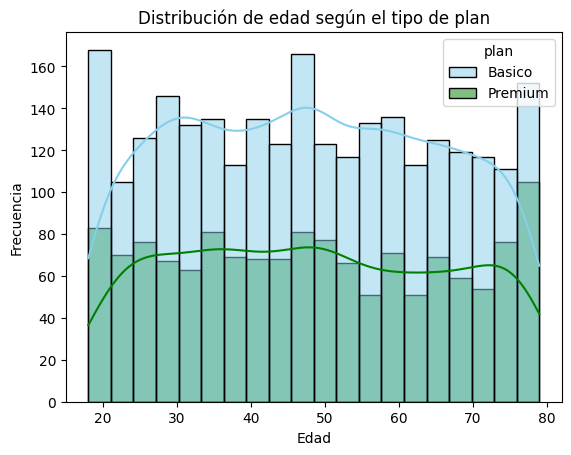

In [ ]:

# Histograma para visualizar la edad (age)

sns.histplot(
    data=user_profile,
    x='age',
    hue='plan',
    bins=20,
    palette=['skyblue', 'green'],
    kde=True
)

plt.title('Distribución de edad según el tipo de plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')

plt.show()

💡Insights:
La distribución de edades es relativamente uniforme en ambos tipos de plan, sin concentraciones extremas en un rango específico.
El plan Basico presenta una mayor cantidad de usuarios en casi todos los rangos de edad, lo cual es consistente con que es el plan más contratado dentro del dataset. Es decir que el plan no se relaciona con la edad.
No se identifican outliers evidentes ni edades fuera de rango después del proceso de limpieza de datos.

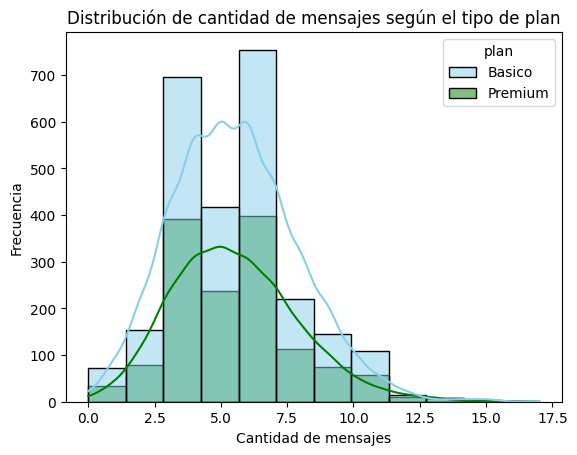

In [ ]:
# Histograma para visualizar la cant_mensajes
sns.histplot(
    data=user_profile,
    x='cant_mensajes',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=12,
    alpha=0.5,
    kde=True
)

# título y etiquetas
plt.title('Distribución de cantidad de mensajes según el tipo de plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Frecuencia')

plt.show()

💡Insights:
- La mayoría de usuarios en ambos planes envían entre 3 y 7 mensajes. El plan Básico concentra más usuarios y no se observan diferencias significativas frente a Premium.

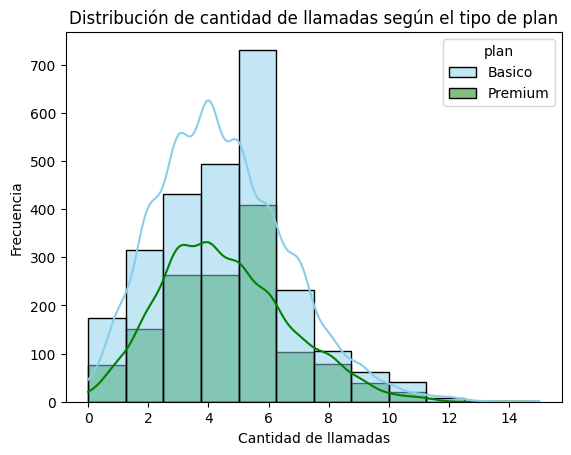

In [ ]:

# Histograma para visualizar la cant_llamadas
sns.histplot(
    data=user_profile,
    x='cant_llamadas',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=12,
    alpha=0.5,
    kde=True
)

# título y etiquetas
plt.title('Distribución de cantidad de llamadas según el tipo de plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Frecuencia')

plt.show()


💡Insights:
Insight 1: Los usuarios Básico concentran su pico en 5–6 llamadas/mes, mientras que Premium lo tienen en 4. Básico tiene una cola más larga (hasta 15 llamadas), sugiriendo mayor variabilidad de uso.
Insight 2: Premium muestra una distribución más estrecha y simétrica. Básico tiene un segundo pico cerca de 2 llamadas, indicando dos subgrupos: usuarios de bajo y alto consumo.

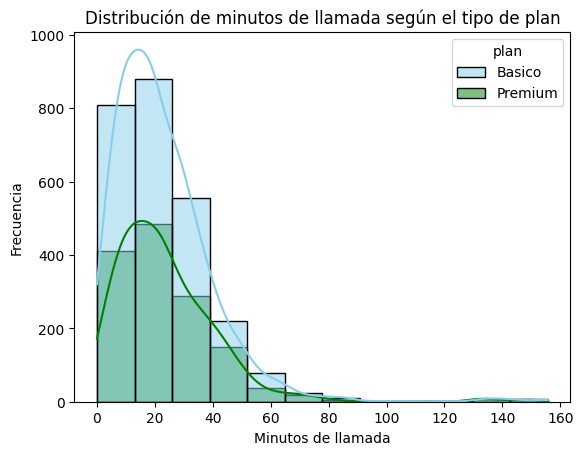

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(
    data=user_profile,
    x='cant_minutos_llamada',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=12,
    alpha=0.5,
    kde=True
)

# título y etiquetas
plt.title('Distribución de minutos de llamada según el tipo de plan')
plt.xlabel('Minutos de llamada')
plt.ylabel('Frecuencia')

plt.show()

💡Insights:
Insight 1: Ambos planes se concentran entre 0–40 minutos, pero Básico tiene su pico más tardío (~20 min) y una cola más larga hasta 160 min, revelando usuarios de conversaciones muy extensas casi ausentes en Premium.
Insight 2: Premium presenta una distribución más compacta y pronunciada con pico en ~15 min. Esto sugiere que sus usuarios hacen llamadas más cortas y homogéneas en duración.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

<Figure size 800x400 with 0 Axes>

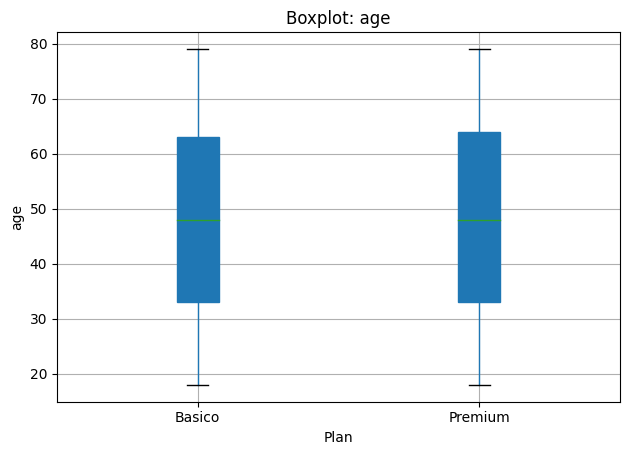

<Figure size 800x400 with 0 Axes>

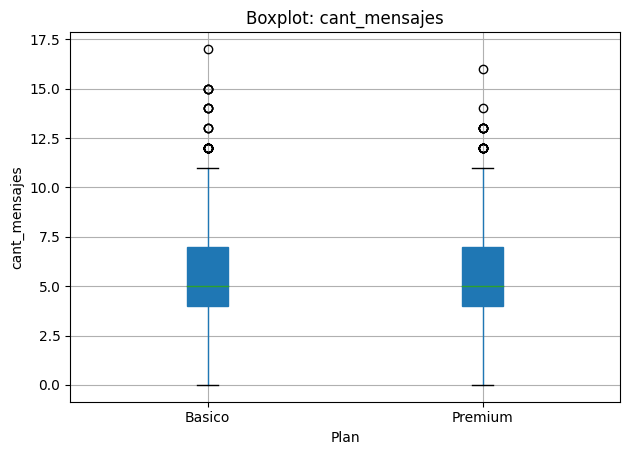

<Figure size 800x400 with 0 Axes>

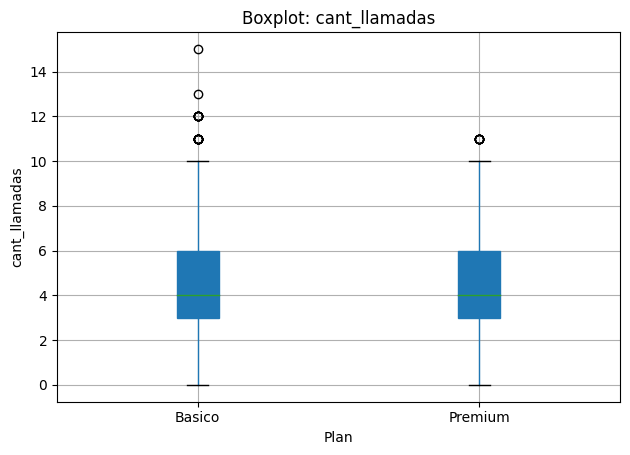

<Figure size 800x400 with 0 Axes>

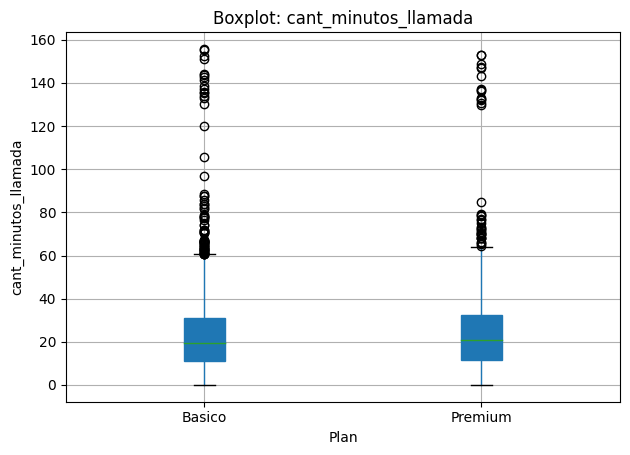

In [ ]:

# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(8, 4))
    user_profile.boxplot(column=col, by='plan', patch_artist=True)
    plt.title(f'Boxplot: {col}')
    plt.suptitle('')
    plt.xlabel('Plan')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()




💡Insights:
-Age: No presenta outliers. Ambos planes tienen una distribución similar con mediana ~49 años y rango entre 18–80, lo que indica una base de usuarios homogénea en edad.
-cant_mensajes: Sí presenta outliers superiores (hasta 17 mensajes). El bigote llega a ~11, por lo que valores sobre ese umbral son atípicos, aunque pocos. La mediana se mantiene en ~5 para ambos planes.
-cant_llamadas: Sí presenta outliers superiores (hasta 15 llamadas). La caja es compacta entre 3–6 llamadas, lo que indica que la mayoría de usuarios tiene un comportamiento consistente y los valores extremos son casos aislados.
-cant_minutos_llamada: Sí presenta outliers superiores, siendo la variable con mayor cantidad y dispersión de valores atípicos (hasta ~160 min). La caja se concentra entre 0–30 min, lo que revela que la mayoría hace llamadas cortas pero existe una minoría con llamadas muy extensas que distorsionan la distribución.


In [ ]:

# Calcular límites con el método IQR

columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + 1.5 * IQR

    print(f"{col} | IQR: {IQR:.2f} | Límite superior: {limite_superior:.2f}")




cant_mensajes | IQR: 3.00 | Límite superior: 11.50
cant_llamadas | IQR: 3.00 | Límite superior: 10.50
cant_minutos_llamada | IQR: 20.30 | Límite superior: 61.86


In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights:

-cant_mensajes (límite superior: 11.5): Se aplica winsorización. Aunque valores de 12–17 mensajes son atípicos frente a la mediana de 5, representan usuarios reales con alto volumen de mensajes. Eliminarlos sesgaría el análisis de ese segmento; winsorizando se conservan los registros ajustando solo el valor extremo.
-cant_llamadas (límite superior: 10.5): Se aplica winsorización. Los valores de 11–15 llamadas son pocos pero corresponden a usuarios existentes con comportamiento intensivo. Mantener la fila con el valor cappado permite conservar el perfil completo del usuario sin distorsionar los promedios generales.
-cant_minutos_llamada (límite superior: 61.86): Se aplica winsorización. Es la variable con mayor volumen y dispersión de outliers (hasta 155 min), lo que confirma un segmento real de usuarios con llamadas muy largas. Winsorizando se preservan todos los registros y se reduce el impacto de los extremos sin perder información valiosa del comportamiento de ese grupo.


---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso

condiciones = [
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10)
]

valores = ['Bajo uso', 'Uso medio']

user_profile['grupo_uso'] = np.select(condiciones, valores, default='Alto uso')


In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,length,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,258.0,Uso medio
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,226.0,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,225.0,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,530.0,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,229.0,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad

condiciones = [
    (user_profile['age'] < 30),
    (user_profile['age'] < 60)
]

valores = [
    'Joven',
    'Adulto'
]

user_profile['grupo_edad'] = np.select(condiciones, valores, default='Adulto Mayor')

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,length,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,258.0,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,226.0,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,225.0,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,530.0,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,229.0,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

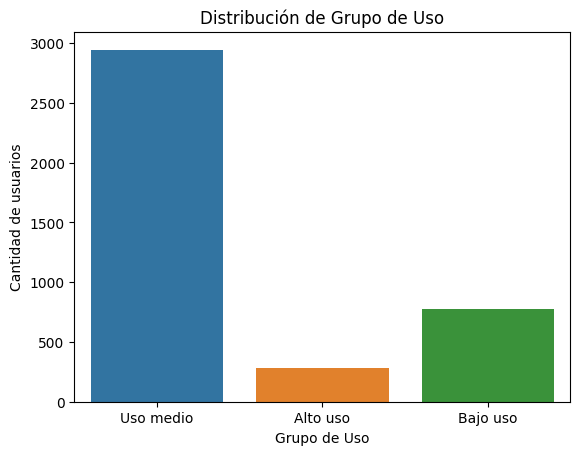

In [ ]:
# Visualización de los segmentos por uso
plt.figure()

sns.countplot(data=user_profile, x='grupo_uso')

plt.title('Distribución de Grupo de Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de usuarios')

plt.show()

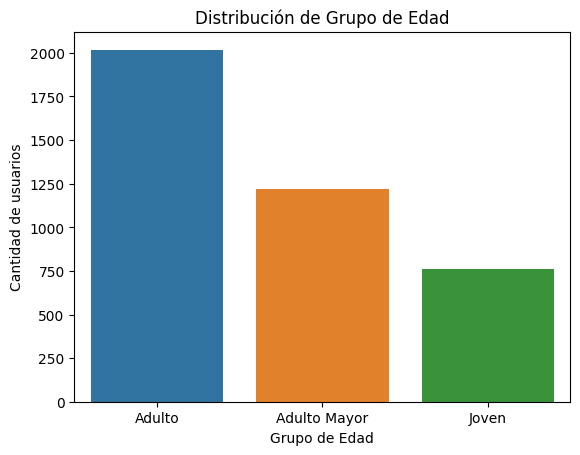

In [ ]:
# Visualización de los segmentos por edad
plt.figure()

sns.countplot(data=user_profile, x='grupo_edad')

plt.title('Distribución de Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de usuarios')

plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**

- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?



- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?



- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?


✍️ **Escribe aquí tu análisis ejecutivo:**

¿Qué problemas tenían originalmente los datos?
Tres variables presentaban outliers superiores que inflaban las medias. cant_minutos_llamada era la más afectada con valores hasta 155 min frente a una mediana de ~20 min. Ninguna variable presentó nulos ni duplicados relevantes, lo que indica un dataset de buena calidad base.
¿Qué segmentos se identificaron?

Por uso: El 74% de los usuarios son de Uso medio (llamadas y mensajes entre 5–10), el 19% son Bajo uso y solo el 7% Alto uso — un segmento pequeño pero de alto valor potencial.
Por edad: El segmento Adulto (30–60 años) domina con 50% de la base, seguido de Adulto Mayor (30%) y Joven (19%).

¿Qué segmentos son más valiosos para ConnectaTel?
El cruce de Alto uso + Adulto representa el perfil de mayor valor: usuarios activos, estables económicamente y con consumo intensivo. Los Adultos Mayores de uso medio también son estratégicos por su volumen y fidelidad potencial.
¿Qué implican los outliers para el negocio?
Los usuarios con llamadas superiores a 60 min y mensajes superiores a 11 son clientes de consumo intensivo que probablemente están siendo subatendidos por los planes actuales. Son candidatos naturales a un plan de mayor capacidad o a ofertas de datos ilimitados.
¿Qué recomendaciones harías?

Crear un plan "Power User" orientado al segmento de Alto uso con minutos y mensajes ilimitados
Diseñar campañas de upselling para usuarios de Uso Medio en plan Básico, que constituyen el mayor volumen del dataset
Desarrollar una oferta Senior para Adultos Mayores con interfaz simplificada y minutos incluidos, dado su peso en la base
Monitorear el segmento Joven de Bajo uso para identificar si es abandono temprano o un nicho a activar con planes de entrada más atractivos


##Análisis Ejecutivo

⚠️ *Problemas detectados en los datos*

Tres variables presentaron outliers superiores: cant_mensajes (hasta 17), cant_llamadas (hasta 15) y cant_minutos_llamada (hasta 160 min). Dado que representan comportamiento real de usuarios activos y no errores de captura, se aplicó winsorización en los tres casos para preservar todos los registros sin distorsionar las distribuciones.
cant_minutos_llamada fue la variable más afectada: la caja se concentra entre 0–30 min pero la cola llega a 160 min, generando un sesgo positivo que inflaba la media significativamente por encima de la mediana (20 min).


🔍 *Segmentos por Edad*

El segmento Adulto (~50% de la base) domina la distribución, seguido de Adulto Mayor (30%) y Joven (19%). La base de usuarios es mayoritariamente madura.
La variable age no presentó outliers y mostró una distribución simétrica con mediana 49 años en ambos planes, lo que indica una base homogénea en edad independientemente del plan contratado.


📊 *Segmentos por Nivel de Uso*

El 74% de los usuarios son de Uso Medio, con llamadas y mensajes entre 5–10. El 19% son Bajo Uso y apenas el 7% Alto Uso.
Pese a ser minoría, los usuarios de Alto Uso concentran los outliers más extremos en llamadas y minutos, con patrones de consumo hasta 3x por encima de la mediana general.

➡️ Esto sugiere que la base de ConnectaTel está compuesta mayoritariamente por usuarios moderados con un segmento pequeño pero intensivo que probablemente está siendo subatendido por los planes actuales, representando una oportunidad directa de upselling y desarrollo de productos.

💡 *Recomendaciones*

Diseñar un plan "Power User" con minutos y mensajes ilimitados orientado al segmento de Alto Uso, capturando a los usuarios con llamadas superiores a 60 min y mensajes superiores a 11 que hoy no tienen una oferta adecuada.
Lanzar una campaña de upselling dirigida al segmento de Uso Medio en plan Básico — el de mayor volumen — con beneficios incrementales que justifiquen la migración a Premium antes de que migren a un competidor.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`